## Inter/Intra FC - parcel space

analysis from numberline/group_comparison_01.ipynb for DNumRisk

In [ ]:
import nibabel as nib
import numpy as np
import os
import pandas as pd
import os.path as op

bids_folder = '/mnt_AdaBD_largefiles/Data/SMILE_Data/DNumRisk/ds-dnumrisk'
dataset_name = 'DNumRisk'
ses = 1

subList = [f'{int(sub):02d}' for sub in range(1, 67)]
subArray = [sub for sub in range(1, 67)]
group_mapping = pd.read_csv(os.path.join(bids_folder, 'group_assignment.csv')).set_index('subject')

from numrisk.fmri_analysis.gradients.utils import get_glasser_parcels, get_glasser_CAatlas_mapping
#mask_glasser, labeling_glasser = get_glasser_parcels(space = 'fsaverage5' )
glasser_CAatlas_mapping, CAatlas_names = get_glasser_CAatlas_mapping()

ci = glasser_CAatlas_mapping['ca_network'].values # community affiliation vector

250922-13:17:46,144 nipype.utils WARNING:
	 A newer version (1.10.0) of nipy/nipype is available. You are using 1.8.6


In [12]:
from utils import threshold_matrix
conn_thresh = 1 #0.15  # Proportion of connections to keep
post_preproc = '36P'

CMs = []
subArray = []
for sub in subList:
    try:
        cm = np.load(os.path.join(bids_folder, 'derivatives', 'correlation_matrices.parcel', f'sub-{sub}_glasserParcel-fsaverage_confspec-36Pscrub3BPfilter.npy'))  # generated with getCM_parcel.py
        cm = threshold_matrix(cm, proportion=conn_thresh)  # Threshold the matrix to keep only the top 15% of connections
        CMs.append(cm)
        subArray.append(sub)
    except FileNotFoundError:
        print(f"File not found for subject {sub}")
subArray = np.array(subArray).astype(int)

In [ ]:
# with old post-preproc CMs loading
post_preproc = 'old'

source_folder = '/mnt_03/ds-dnumrisk/derivatives/correlation_matrices'
spec =  ''
space = 'fsaverage'  # 'fsaverage5'

CMs= [None] * len(subList)
for i,sub in enumerate(subList):
    cm_file = op.join(source_folder,f'sub-{sub}_glasserParcel-{space}{spec}.npy')
    cm = np.load(cm_file)
    CMs[i] = cm

CMs = np.array(CMs)
np.shape(CMs)

In [13]:
from scipy.stats import ttest_ind

CMs_array = np.transpose(np.array(CMs), (1, 2, 0)) 

N_nets = 12

mat_tstat = np.zeros([N_nets, N_nets])
mat_pvals = np.ones([N_nets, N_nets])
average_mean_BN_fc_strength = np.zeros([N_nets, N_nets])

for seed_net in range(1,N_nets+1):
    for target_net in range(seed_net, N_nets+1):
        network_seed_indices = np.where(glasser_CAatlas_mapping['ca_network'] == seed_net)[0]
        network_target_indices = np.where(glasser_CAatlas_mapping['ca_network'] == target_net)[0]
        
        mean_BN_fc_strength = CMs_array[np.ix_(network_seed_indices, network_target_indices)].mean(axis=(0,1))
        average_mean_BN_fc_strength[seed_net-1, target_net-1] = mean_BN_fc_strength.mean()
        
        df_mBNfc = pd.DataFrame(mean_BN_fc_strength, index=subArray, columns=['mean_BN_fc_strength'])   
        df_mBNfc.index.name = 'subject'
        df_mBNfc = df_mBNfc.join(group_mapping, on='subject')

        stats = ttest_ind(df_mBNfc[df_mBNfc['group'] == 0]['mean_BN_fc_strength'], df_mBNfc[df_mBNfc['group'] == 1]['mean_BN_fc_strength'], axis=0, equal_var=False)
        mat_tstat[seed_net-1, target_net-1] = stats.statistic
        mat_pvals[seed_net-1, target_net-1] = stats.pvalue
        

Text(0.5, 1.0, 'Inter/Intra-Network FC DNumRisk \n T-stats (blue larger in DD), thresh=1, post-preproc = 36P')

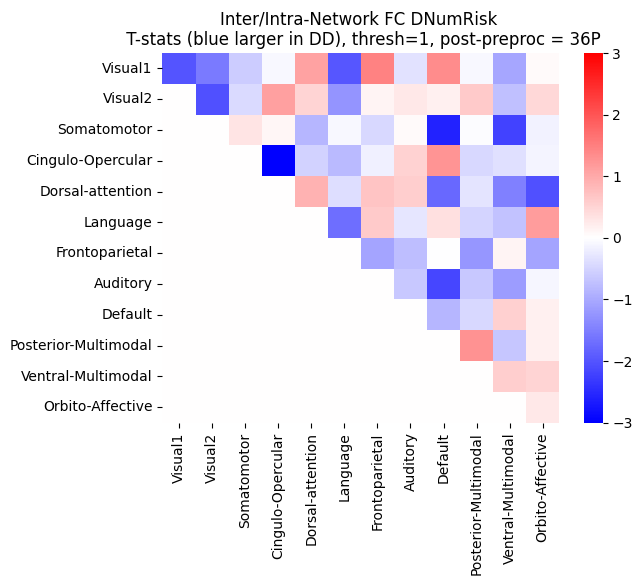

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(mat_tstat, cmap='bwr',vmin=-3,vmax=3,
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'Inter/Intra-Network FC {dataset_name} \n T-stats (blue larger in DD), thresh={conn_thresh}, post-preproc = {post_preproc}' )

Text(0.5, 1.0, 'Inter/Intra-Network FC DNumRisk \n p-vals, thresh=1')

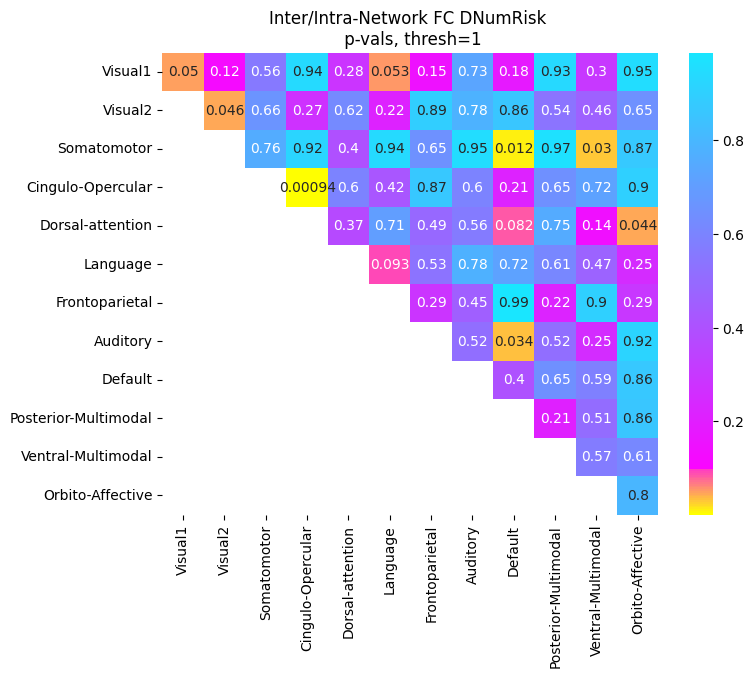

In [15]:
from numrisk.fmri_analysis.gradients.utils_02 import get_pval_colormap

pval_cmap = get_pval_colormap()

mat_pvals_ = mat_pvals.copy()
mat_pvals_[np.tril_indices_from(mat_pvals_, k=-1)] = np.nan

fig, axes = plt.subplots(1,1, figsize=(8,6)) 
sns.heatmap(mat_pvals_, cmap=pval_cmap,annot=True,ax=axes,#vmin=-0.4,vmax=0.4,
            xticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)],
            yticklabels=[str(CAatlas_names.loc[i+1]['Network Name']) for i in range(N_nets)])
plt.title(f'Inter/Intra-Network FC {dataset_name} \n p-vals, thresh={conn_thresh}' )